# Prétraitement du dataset `bottle` (détection d'anomalies, format MVTec-AD)

Ce notebook implémente le pipeline décrit dans `preprocessing_bottle_fr.md` :

1. Inventaire et vérification des fichiers (images + masques).
2. Redimensionnement des images (128×128 ou 256×256) et des masques (`ground_truth`).
3. Normalisation des pixels dans `[0, 1]`.
4. Split train/validation sur les images saines uniquement.
5. Augmentation (Albumentations) appliquée uniquement à l'entraînement.
6. Pipeline `tf.data` performant (chargement, batching, prefetch).

**Bibliothèques** : `pillow` (I/O), `opencv` (resize images), `scikit-image` (resize masques binaires), `albumentations` (augmentation), `tensorflow` (pipeline final).

> Adapter `DATA_DIR` au chemin réel de ton dataset `bottle` avant exécution.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # réduit les logs TensorFlow

from pathlib import Path
import numpy as np
import cv2
from PIL import Image
from skimage.transform import resize as sk_resize
import albumentations as A
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Configuration (correspond à la section 1 du md — choix de la taille cible)

In [2]:
DATA_DIR = Path("data/bottle")   # <- à adapter à ton chemin local
IMG_SIZE = 128                    # 128 pour itérer vite, 256 pour la version finale
BATCH_SIZE = 16
VAL_FRACTION = 0.15
SEED = 42

np.random.seed(SEED)

## Étape 3.1 — Inventaire et vérification des fichiers

- Liste des images saines (`train/good`, `test/good`) et des dossiers de défauts (`test/<defect>`).
- Vérification que chaque image défectueuse a bien son masque correspondant dans `ground_truth/<defect>`.
- Détection de fichiers corrompus.

In [3]:
train_good = sorted((DATA_DIR / "train" / "good").glob("*.png"))
test_good = sorted((DATA_DIR / "test" / "good").glob("*.png"))
defect_dirs = [d for d in (DATA_DIR / "test").iterdir() if d.is_dir() and d.name != "good"]
defect_names = sorted(d.name for d in defect_dirs)

print("train/good :", len(train_good))
print("test/good  :", len(test_good))
print("classes de défauts :", defect_names)

train/good : 209
test/good  : 20
classes de défauts : ['broken_large', 'broken_small', 'contamination']


In [4]:
# Vérifie la correspondance image <-> masque pour chaque classe de défaut
# Convention MVTec-AD : ground_truth/<defect>/<id>_mask.png <-> test/<defect>/<id>.png
for name in defect_names:
    imgs = sorted((DATA_DIR / "test" / name).glob("*.png"))
    masks = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    assert len(imgs) == len(masks), f"Mismatch images/masks pour {name}: {len(imgs)} vs {len(masks)}"
    print(f"  {name}: {len(imgs)} images / {len(masks)} masks — OK")

  broken_large: 20 images / 20 masks — OK
  broken_small: 22 images / 22 masks — OK
  contamination: 21 images / 21 masks — OK


In [5]:
def verify_images(paths):
    """Retourne la liste des fichiers illisibles/corrompus."""
    bad = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            bad.append(p)
    return bad

bad_files = verify_images(train_good + test_good)
print("Fichiers corrompus détectés :", len(bad_files))
if bad_files:
    print(bad_files)

Fichiers corrompus détectés : 0


## Étapes 3.2 à 3.4 — Chargement, redimensionnement (images + masques) et normalisation

- **Images** : Pillow pour la lecture (conversion RGB systématique), OpenCV pour le resize (`INTER_AREA`, adapté à la réduction de taille).
- **Masques** : lecture Pillow en niveaux de gris, resize scikit-image en **plus proche voisin** (`order=0`) pour ne pas casser la binarité, puis re-binarisation explicite.

In [6]:
def load_and_resize_image(path, size=IMG_SIZE):
    """Charge une image et la redimensionne en (size, size, 3), RGB, uint8."""
    img = Image.open(path).convert("RGB")
    img = np.array(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img


def load_and_resize_mask(path, size=IMG_SIZE):
    """Charge un masque binaire et le redimensionne sans casser la binarité."""
    mask = Image.open(path).convert("L")
    mask = np.array(mask)
    mask = sk_resize(mask, (size, size), order=0, preserve_range=True, anti_aliasing=False)
    mask = (mask > 127).astype(np.uint8)
    return mask


def normalize(img):
    """Normalise une image uint8 [0,255] en float32 [0,1]."""
    return img.astype(np.float32) / 255.0

In [7]:
# Vérification rapide sur un exemple
sample_img = load_and_resize_image(train_good[0])
print("Image redimensionnée :", sample_img.shape, sample_img.dtype)

if defect_names:
    sample_mask_path = sorted((DATA_DIR / "ground_truth" / defect_names[0]).glob("*_mask.png"))[0]
    sample_mask = load_and_resize_mask(sample_mask_path)
    print("Masque redimensionné :", sample_mask.shape, "valeurs uniques :", np.unique(sample_mask))

sample_norm = normalize(sample_img)
print("Image normalisée, plage :", sample_norm.min(), "-", sample_norm.max())

Image redimensionnée : (128, 128, 3) uint8
Masque redimensionné : (128, 128) valeurs uniques : [0 1]
Image normalisée, plage : 0.12156863 - 1.0


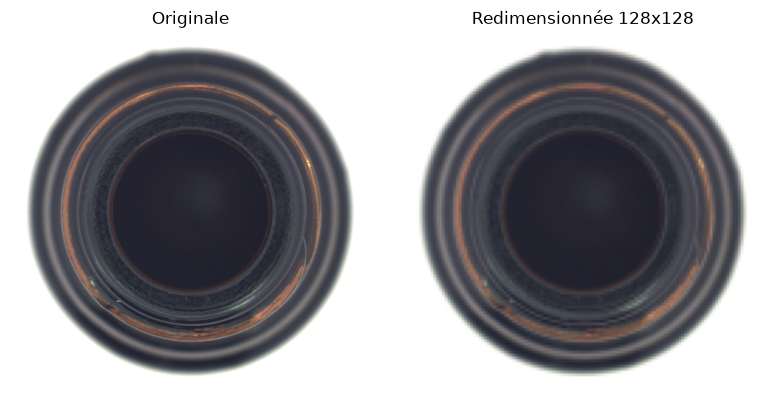

In [8]:
# Aperçu visuel : image originale vs redimensionnée
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(train_good[0]).convert("RGB"))
axes[0].set_title("Originale")
axes[0].axis("off")
axes[1].imshow(sample_img)
axes[1].set_title(f"Redimensionnée {IMG_SIZE}x{IMG_SIZE}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Étape 3.5 — Split train / validation (images saines uniquement)

Split aléatoire sur les chemins de fichiers de `train/good`, avant tout chargement en mémoire. Les dossiers `test/` (sains et défectueux) ne sont jamais utilisés pour ce split — ils servent uniquement à l'évaluation finale.

In [9]:
train_paths, val_paths = train_test_split(
    train_good, test_size=VAL_FRACTION, random_state=SEED
)
print(f"Train : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} images")

Train : 177 images
Validation : 32 images


## Étape 3.6 — Pipeline d'augmentation (Albumentations) — images saines d'entraînement uniquement

Transformations choisies, cohérentes avec un contexte industriel (une bouteille doit rester reconnaissable comme "normale") :
- `HorizontalFlip` — symétrie horizontale
- `Rotate` — rotation légère (±15°)
- `ShiftScaleRotate` — translation + mise à l'échelle légère (centrage/zoom imparfait de la caméra)
- `RandomBrightnessContrast` — variations d'éclairage

Appliquées uniquement sur le split d'entraînement (`train_paths`), jamais sur validation/test.

In [10]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_REPLICATE),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
        border_mode=cv2.BORDER_REPLICATE, p=0.5,
    ),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])

e:\Projets\_workspace\aelion-4-trainning\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


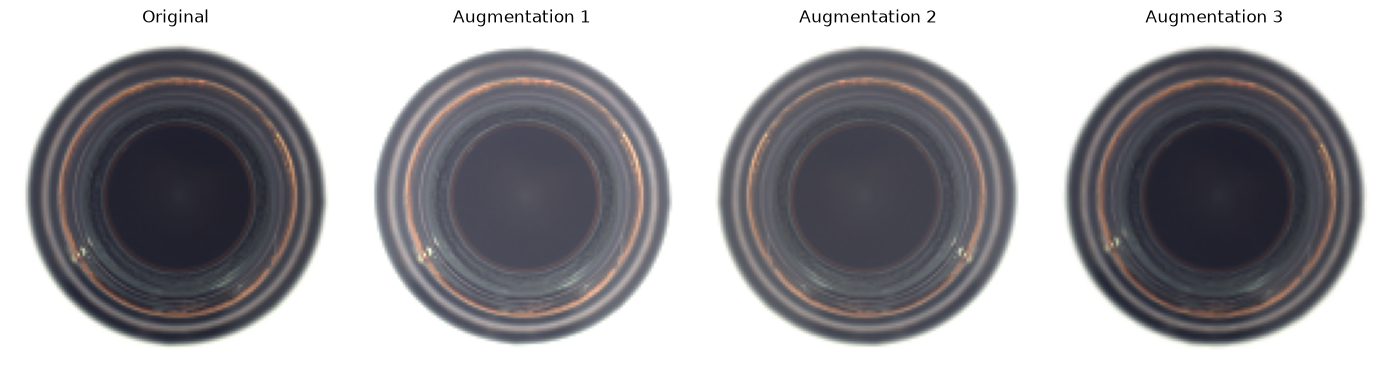

In [11]:
# Aperçu rapide de quelques tirages d'augmentation sur une même image
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
base_img = load_and_resize_image(train_paths[0])
axes[0].imshow(base_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 4):
    aug_img = train_transform(image=base_img)["image"]
    axes[i].imshow(aug_img); axes[i].set_title(f"Augmentation {i}"); axes[i].axis("off")
plt.tight_layout()
plt.show()

## Étape 3.7 — Vérification visuelle de l'augmentation (original vs augmenté)

Pour confirmer que le pipeline d'augmentation produit des transformations réalistes (et qu'il n'est pas un no-op), on compare, pour plusieurs images saines différentes :
- l'image **originale** redimensionnée (ligne du haut)
- **plusieurs tirages augmentés** de la même image (lignes suivantes — chaque appel du pipeline étant stochastique)

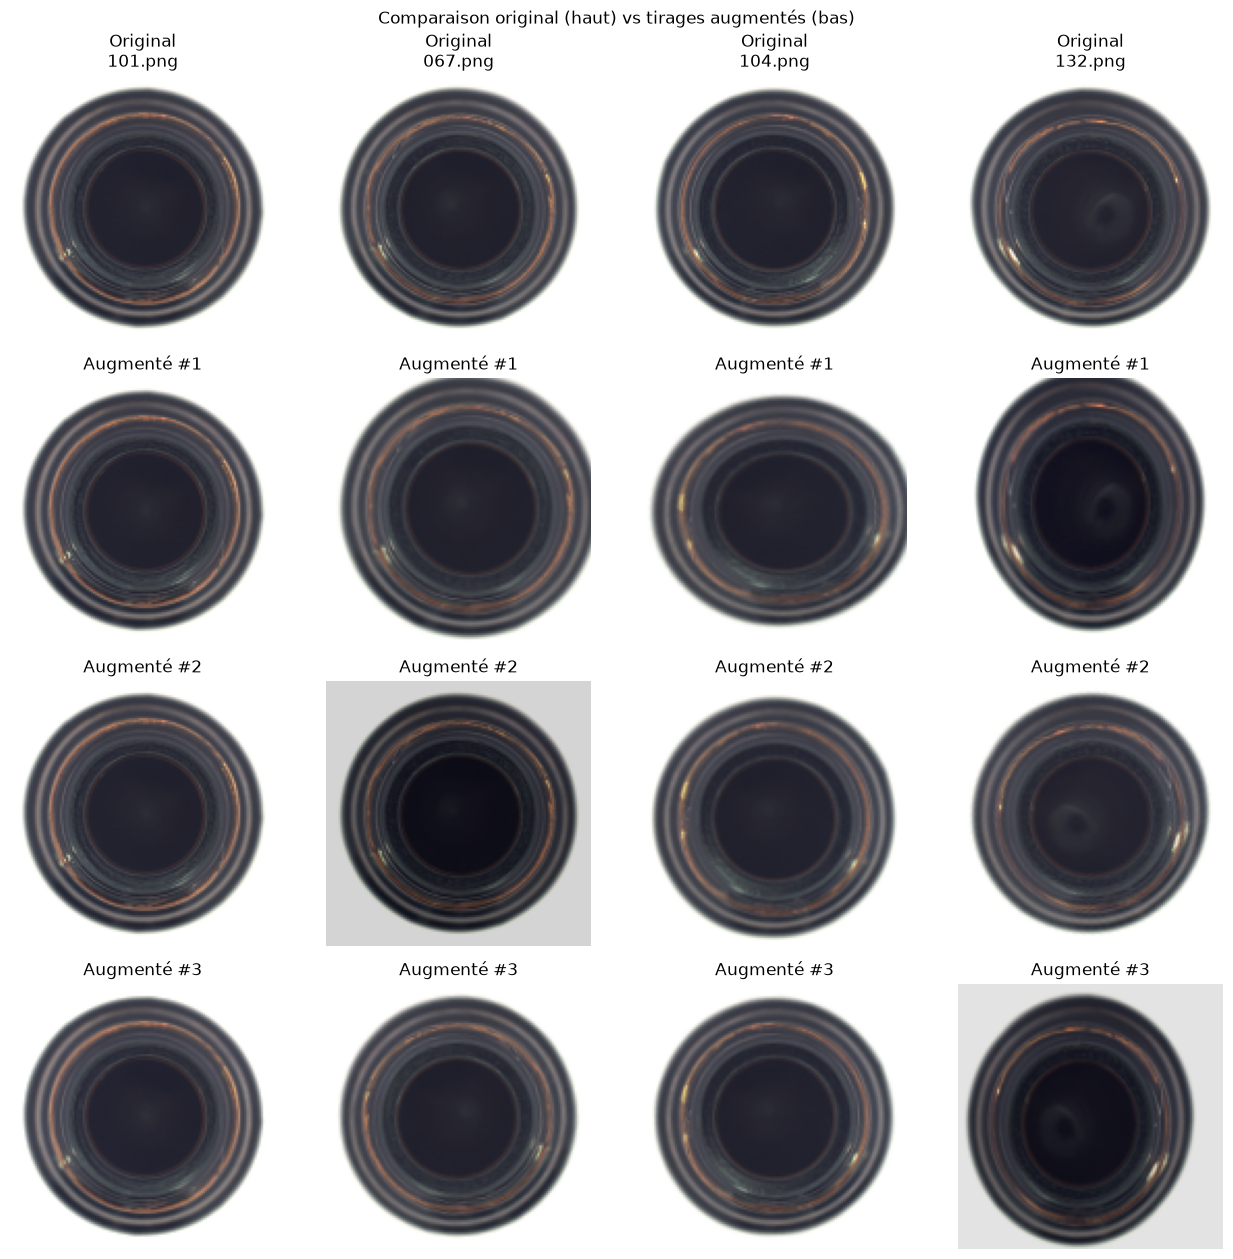

In [12]:
N_IMAGES = 4      # nombre d'images saines comparées
N_DRAWS = 3        # nombre de tirages augmentés par image

fig, axes = plt.subplots(N_DRAWS + 1, N_IMAGES, figsize=(3.2 * N_IMAGES, 3.2 * (N_DRAWS + 1)))

for col in range(N_IMAGES):
    path = train_paths[col]
    original = load_and_resize_image(path)

    axes[0, col].imshow(original)
    axes[0, col].set_title(f"Original\n{path.name}")
    axes[0, col].axis("off")

    for row in range(1, N_DRAWS + 1):
        augmented = train_transform(image=original)["image"]
        axes[row, col].imshow(augmented)
        axes[row, col].set_title(f"Augmenté #{row}")
        axes[row, col].axis("off")

plt.suptitle("Comparaison original (haut) vs tirages augmentés (bas)")
plt.tight_layout()
plt.show()

## Étape 3.8 — Vérification visuelle du chargement

Avant de construire le pipeline `tf.data`, on affiche une grille d'images chargées/redimensionnées :
- quelques images **saines** (`train/good`)
- quelques images de **chaque défaut** (`test/<defect>`), avec leur masque `ground_truth` superposé

Objectif : détecter à l'œil un souci de chargement (inversion BGR/RGB, mauvais alignement image/masque, resize qui écrase l'information) avant d'aller plus loin.

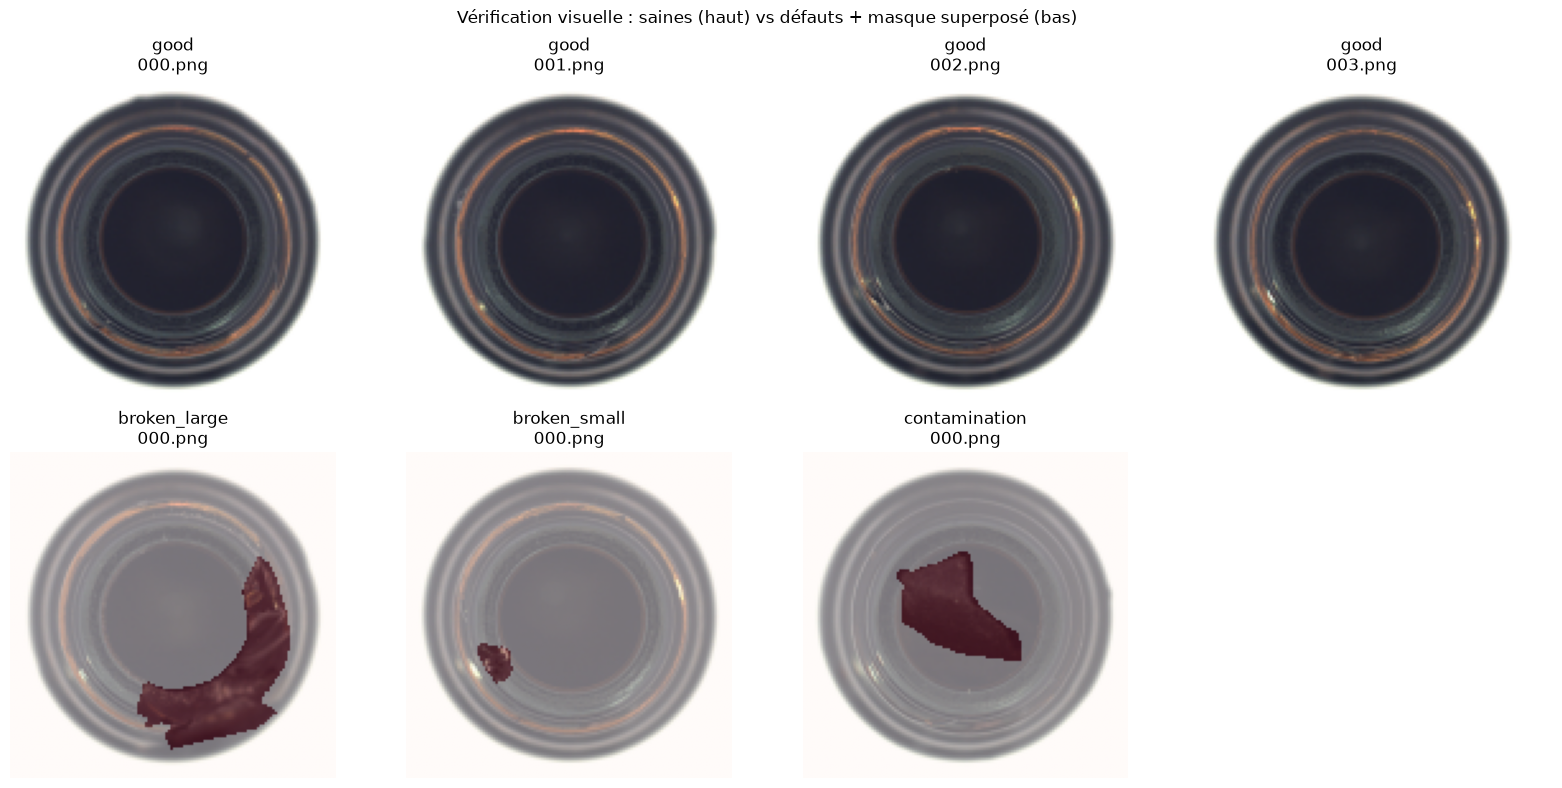

In [13]:
N_SAMPLES = 4

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 8))

# Ligne 1 : images saines
for i, path in enumerate(train_good[:N_SAMPLES]):
    img = load_and_resize_image(path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"good\n{path.name}")
    axes[0, i].axis("off")

# Ligne 2 : un défaut par colonne (image + masque superposé)
n_defects_shown = min(N_SAMPLES, len(defect_names))
for i in range(N_SAMPLES):
    axes[1, i].axis("off")
for i, name in enumerate(defect_names[:n_defects_shown]):
    img_path = sorted((DATA_DIR / "test" / name).glob("*.png"))[0]
    mask_path = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))[0]
    img = load_and_resize_image(img_path)
    mask = load_and_resize_mask(mask_path)

    axes[1, i].imshow(img)
    axes[1, i].imshow(mask, cmap="Reds", alpha=0.4)  # masque en surimpression
    axes[1, i].set_title(f"{name}\n{img_path.name}")
    axes[1, i].axis("off")

plt.suptitle("Vérification visuelle : saines (haut) vs défauts + masque superposé (bas)")
plt.tight_layout()
plt.show()

## Étape 3.9 — Construction du pipeline `tf.data` (entraînement / validation)

- `load_and_resize_image` (Pillow/OpenCV) et Albumentations ne sont pas nativement compatibles avec le graphe TensorFlow → encapsulation via `tf.py_function`.
- Augmentation appliquée uniquement si `augment=True` (train), jamais pour validation/test.
- `.cache()` optionnel si le dataset tient en mémoire (cas de `bottle`, quelques centaines d'images).

In [14]:
def make_loader(augment: bool):
    def _load(path):
        path = path.numpy().decode("utf-8")
        img = load_and_resize_image(path)
        if augment:
            img = train_transform(image=img)["image"]
        img = normalize(img)
        return img.astype(np.float32)

    def _tf_wrapper(path):
        img = tf.py_function(_load, [path], tf.float32)
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        return img
    return _tf_wrapper


def build_dataset(paths, augment=False, shuffle=False, batch_size=BATCH_SIZE, cache=True):
    paths_str = [str(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices(paths_str)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths_str), seed=SEED)
    ds = ds.map(make_loader(augment), num_parallel_calls=tf.data.AUTOTUNE)
    if cache and not augment:
        # pas de cache si augmentation (on veut une augmentation différente à chaque epoch)
        ds = ds.cache()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [15]:
train_ds = build_dataset(train_paths, augment=True, shuffle=True)
val_ds = build_dataset(val_paths, augment=False, shuffle=False)

for batch in train_ds.take(1):
    print("Batch shape :", batch.shape)
    print("dtype :", batch.dtype)
    print("Plage de valeurs :", float(tf.reduce_min(batch)), "-", float(tf.reduce_max(batch)))

Batch shape : (16, 128, 128, 3)
dtype : <dtype: 'float32'>
Plage de valeurs : 0.0 - 1.0


## Étape 3.10 — Construction des datasets de test (évaluation)

- `test/good` + chaque `test/<defect>` : **pas d'augmentation**, juste resize + normalisation.
- Masques `ground_truth/<defect>` redimensionnés en parallèle pour l'évaluation pixel-level future (IoU, AUC-ROC pixel).

In [16]:
test_good_ds = build_dataset(test_good, augment=False, shuffle=False, cache=False)

test_defect_ds = {}
test_defect_masks = {}
for name in defect_names:
    imgs = sorted((DATA_DIR / "test" / name).glob("*.png"))
    masks = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    test_defect_ds[name] = build_dataset(imgs, augment=False, shuffle=False, cache=False)
    test_defect_masks[name] = np.stack([load_and_resize_mask(m) for m in masks])
    print(f"{name}: dataset images prêt, masques shape={test_defect_masks[name].shape}")

broken_large: dataset images prêt, masques shape=(20, 128, 128)
broken_small: dataset images prêt, masques shape=(22, 128, 128)
contamination: dataset images prêt, masques shape=(21, 128, 128)


## Étape 3.11 — Étude de déséquilibre de classe

Deux niveaux à étudier, tous les deux dans `test/` (`train/good` n'a qu'une seule classe) :
- **Niveau image** : proportion saines vs défectueuses, et répartition entre types de défauts.
- **Niveau pixel** : à l'intérieur de chaque masque, fraction de pixels "défaut" vs "fond" — pertinent seulement si un modèle de segmentation est envisagé.

In [17]:
# --- Niveau image : comptage par classe ---
n_good_test = len(test_good)
n_defect_total = sum(len(v) for v in test_defect_masks.values())

print("train/good:", len(train_good))
print("test/good:", n_good_test)
for name in defect_names:
    print(f"test/{name}:", test_defect_masks[name].shape[0])

print(f"\nRatio saines/défectueuses (test) : {n_good_test}/{n_good_test + n_defect_total}"
      f" ({n_good_test/(n_good_test+n_defect_total):.1%}) vs "
      f"{n_defect_total}/{n_good_test + n_defect_total} ({n_defect_total/(n_good_test+n_defect_total):.1%})")

train/good: 209
test/good: 20
test/broken_large: 20
test/broken_small: 22
test/contamination: 21

Ratio saines/défectueuses (test) : 20/83 (24.1%) vs 63/83 (75.9%)


In [18]:
# --- Niveau pixel : fraction de pixels défectueux par masque (résolution originale) ---
pixel_fractions = {}
for name in defect_names:
    mask_paths = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    fracs = []
    for p in mask_paths:
        m = np.array(Image.open(p).convert("L"))
        fracs.append((m > 127).sum() / m.size)
    pixel_fractions[name] = np.array(fracs)
    print(f"{name}: frac pixels défectueux — min={fracs and min(fracs):.4f} "
          f"mean={pixel_fractions[name].mean():.4f} max={pixel_fractions[name].max():.4f}")

broken_large: frac pixels défectueux — min=0.0409 mean=0.1170 max=0.2742
broken_small: frac pixels défectueux — min=0.0088 mean=0.0307 max=0.0806
contamination: frac pixels défectueux — min=0.0058 mean=0.0849 max=0.1653


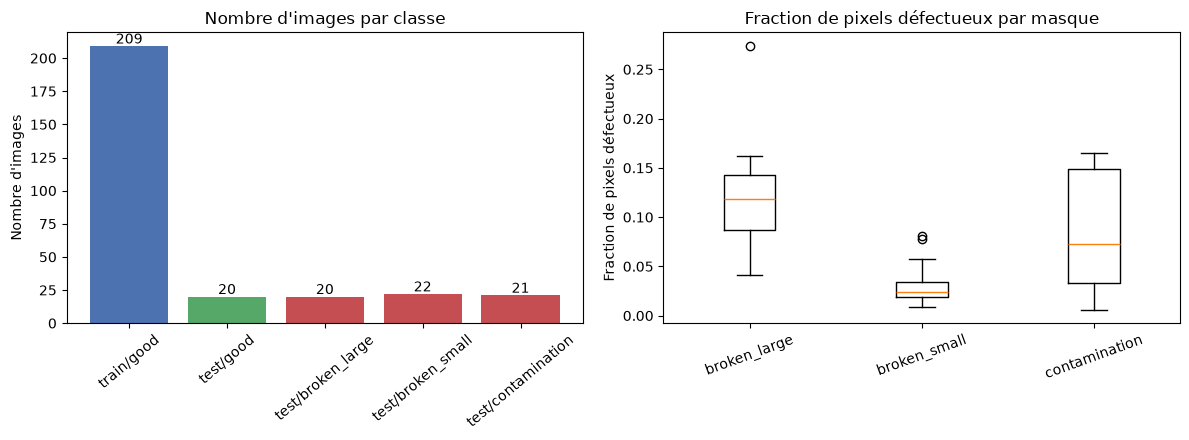

In [19]:
# --- Synthèse visuelle : comptage par classe + distribution des fractions de pixels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = ["train/good", "test/good"] + [f"test/{n}" for n in defect_names]
counts = [len(train_good), n_good_test] + [test_defect_masks[n].shape[0] for n in defect_names]
colors = ["#4C72B0", "#55A868"] + ["#C44E52"] * len(defect_names)
axes[0].bar(labels, counts, color=colors)
axes[0].set_title("Nombre d'images par classe")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis="x", rotation=40)
for i, c in enumerate(counts):
    axes[0].text(i, c + 2, str(c), ha="center")

axes[1].boxplot([pixel_fractions[n] for n in defect_names], tick_labels=defect_names)
axes[1].set_title("Fraction de pixels défectueux par masque")
axes[1].set_ylabel("Fraction de pixels défectueux")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Résumé (correspond aux sections 4 à 6 du md — arborescence, points de vigilance, prochaine étape)

| Étape (md) | Contenu | Statut |
|---|---|---|
| 3.1 | Inventaire + vérification fichiers | ✅ |
| 3.2 | Resize images ({IMG_SIZE}×{IMG_SIZE}) | ✅ |
| 3.3 | Resize masques (binaire préservé) | ✅ |
| 3.4 | Normalisation [0, 1] | ✅ |
| 3.5 | Split train/validation (images saines) | ✅ |
| 3.6 | Pipeline d'augmentation (Albumentations) | ✅ |
| 3.7 | Vérification visuelle de l'augmentation | ✅ |
| 3.8 | Vérification visuelle du chargement | ✅ |
| 3.9 | Pipeline `tf.data` (train/validation) | ✅ |
| 3.10 | Datasets de test (évaluation) | ✅ |
| 3.11 | Étude de déséquilibre de classe | ✅ |

**Prochaine étape** (section 6 du md) : définir l'architecture du modèle (autoencodeur convolutif pour la reconstruction, ou approche par extraction de features + distance type PaDiM) et le protocole d'évaluation (AUC-ROC image-level sur `test/`, IoU/AUC-ROC pixel-level via `ground_truth/`).